In [78]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima_model import ARMA,ARMAResults,ARIMA,ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf 
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

def adf_test(series, title=""):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f"Augmented Dickey-Fuller Test: {title}")
    result = adfuller(
        series.dropna(), autolag="AIC"
    )  # .dropna() handles differenced data

    labels = ["ADF test statistic", "p-value", "# lags used", "# observations"]
    out = pd.Series(result[0:4], index=labels)

    for key, val in result[4].items():
        out[f"critical value ({key})"] = val

    print(out.to_string())  # .to_string() removes the line "dtype: float64"

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

In [79]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)
df.head()

,Cliente,Nº Cliente,UC,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,Lucile Confecções LTDA,7.005714e+09,3003858507,1246.0,1081.0,1184.0,1549.0,2045.0,4017.0,2386.0,...,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
1,CLL Hotel e Turismo,7.008529e+09,3001084033,7160.0,6520.0,6840.0,7440.0,6920.0,6920.0,7240.0,...,52317,48122,50739,48737,52874,56271,51096,53430,45995,51054
2,Academia Planeta Corpo,7.005369e+09,3011373971,440.0,600.0,680.0,760.0,560.0,520.0,320.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MD Predial,7.005492e+09,3001449459,960.0,920.0,1120.0,1040.0,1120.0,1240.0,1000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MD Predial,7.005492e+09,3011504476,1560.0,1280.0,1360.0,1680.0,1680.0,2920.0,1960.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
# Removendo dados desnecessários
df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

In [81]:
# Ajustando o dataset
df_test = df.head()
df_test

,UC,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,2020-01-01 00:00:00,2020-02-01 00:00:00,...,2022-05-01 00:00:00,2022-06-01 00:00:00,2022-07-01 00:00:00,2022-08-01 00:00:00,2022-09-01 00:00:00,2022-10-01 00:00:00,2022-11-01 00:00:00,2022-12-01 00:00:00,2023-01-01 00:00:00,2023-02-01 00:00:00
0,3003858507,1246.0,1081.0,1184.0,1549.0,2045.0,4017.0,2386.0,4239.0,2854.0,...,2478.0,817.0,601.0,638.0,686.0,1216.0,1335.0,1317.0,2367.0,3056.0
1,3001084033,7160.0,6520.0,6840.0,7440.0,6920.0,6920.0,7240.0,6560.0,7440.0,...,6800.0,6760.0,6280.0,5560.0,6360.0,7440.0,7240.0,7960.0,5880.0,7560.0
2,3011373971,440.0,600.0,680.0,760.0,560.0,520.0,320.0,440.0,280.0,...,680.0,840.0,800.0,760.0,840.0,920.0,360.0,680.0,800.0,480.0
3,3001449459,960.0,920.0,1120.0,1040.0,1120.0,1240.0,1000.0,1120.0,1200.0,...,800.0,720.0,880.0,680.0,800.0,1000.0,840.0,880.0,840.0,760.0
4,3011504476,1560.0,1280.0,1360.0,1680.0,1680.0,2920.0,1960.0,2280.0,2480.0,...,1840.0,1600.0,1480.0,1440.0,1720.0,2280.0,2000.0,2160.0,2120.0,2680.0


In [82]:
# Corrigindo os dados para uso das fórmulas
df_test_transpose1 = df_test.transpose()
df_test_transpose = df_test_transpose1.rename(columns=df_test_transpose1.iloc[0])
df_test_transpose.drop("UC", inplace=True, axis=0)
df_test_transpose.dropna(inplace=True)
df_test_transpose

,3003858507,3001084033,3011373971,3001449459,3011504476
2019-06-01 00:00:00,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01 00:00:00,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01 00:00:00,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01 00:00:00,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01 00:00:00,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01 00:00:00,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01 00:00:00,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01 00:00:00,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01 00:00:00,2854.0,7440.0,280.0,1200.0,2480.0
2020-03-01 00:00:00,3208.0,7440.0,320.0,1360.0,2240.0


In [83]:
# transformando índice em datetime
df_test_transpose.index
some_dates = np.array(df_test_transpose.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(some_dates)
df_test_transpose["idx"] = idx
df_test_transpose.set_index("idx", inplace=True)
df_test_transpose

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [84]:
df_test_transpose.columns

Index([3003858507, 3001084033, 3011373971, 3001449459, 3011504476], dtype='object')

In [85]:
df_test_transpose.index.freq = "MS"
df_test_transpose.index

DatetimeIndex(['2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01',
               '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01',
               '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01',
               '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01',
               '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01',
               '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01',
               '2021-06-01', '2021-07-01', '2021-08-01', '2021-09-01',
               '2021-10-01', '2021-11-01', '2021-12-01', '2022-01-01',
               '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01',
               '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01',
               '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01',
               '2023-02-01'],
              dtype='datetime64[s]', name='idx', freq='MS')

In [86]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

span = 12
alpha = 2 / (span + 1)

df_test_transpose["SES"] = (
    SimpleExpSmoothing(df_test_transpose[3003858507].astype(float))
    .fit(smoothing_level=alpha, optimized=False)
    .fittedvalues
)

<Axes: xlabel='idx'>

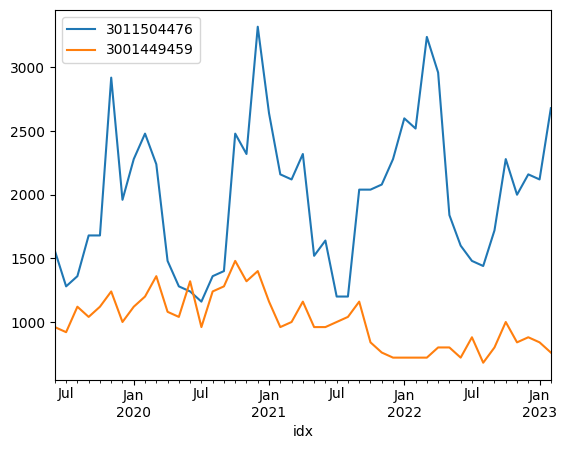

In [193]:
df_test_transpose[[3011504476, 3001449459]].plot()

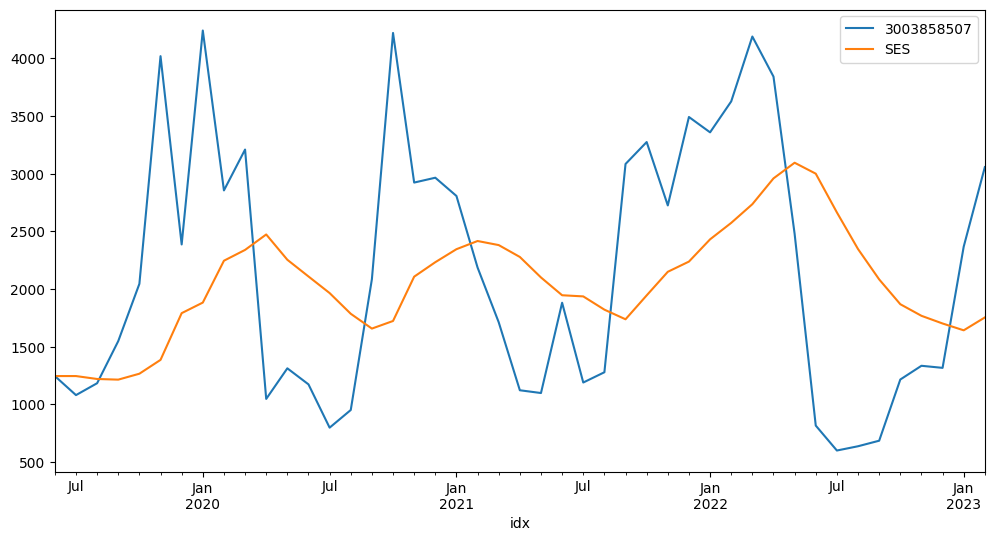

In [87]:
df_test_transpose[[3003858507, "SES"]].plot(figsize=(12, 6)).autoscale(
    axis="x", tight=True
)

In [88]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df_test_transpose["HWadd"] = (
    ExponentialSmoothing(
        df_test_transpose[3003858507].astype(float),
        trend="add",
        seasonal="add",
        seasonal_periods=6,
    )
    .fit()
    .fittedvalues
)
df_test_transpose["HWmul"] = (
    ExponentialSmoothing(
        df_test_transpose[3003858507].astype(float),
        trend="mul",
        seasonal="mul",
        seasonal_periods=6,
    )
    .fit()
    .fittedvalues
)

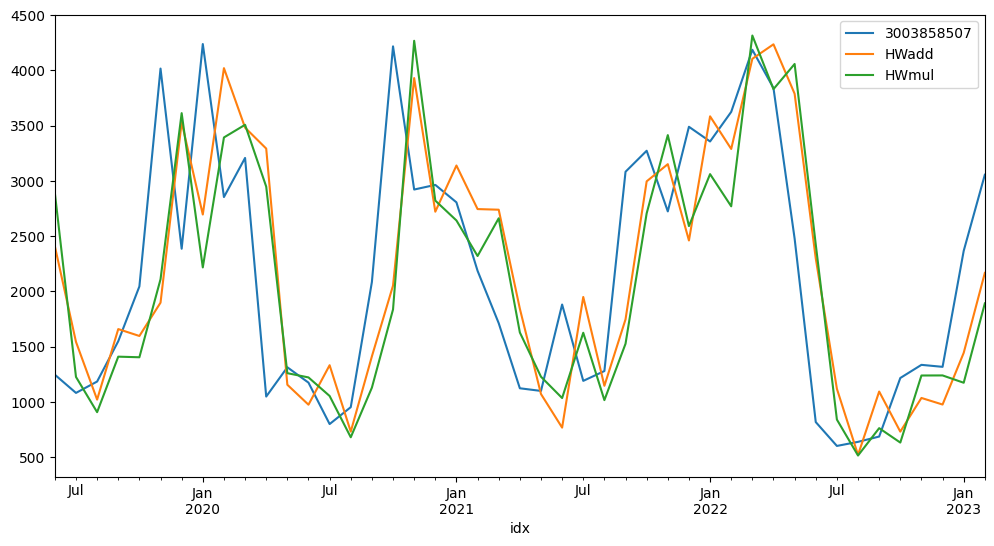

In [89]:
df_test_transpose[[3003858507, "HWadd", "HWmul"]].plot(figsize=(12, 6)).autoscale(
    axis="x", tight=True
)

In [90]:
df_test_transpose.info()
df_test_transpose.drop(["SES", "HWadd", "HWmul"], axis=1, inplace=True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45 entries, 2019-06-01 to 2023-02-01
Freq: MS
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   3003858507  45 non-null     object 
 1   3001084033  45 non-null     object 
 2   3011373971  45 non-null     object 
 3   3001449459  45 non-null     object 
 4   3011504476  45 non-null     object 
 5   SES         45 non-null     float64
 6   HWadd       45 non-null     float64
 7   HWmul       45 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.2+ KB


In [91]:
train_data = df_test_transpose.loc[:"2022-09-01"]
test_data = df_test_transpose.loc["2022-09-01":]
test_data

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2022-09-01,686.0,6360.0,840.0,800.0,1720.0
2022-10-01,1216.0,7440.0,920.0,1000.0,2280.0
2022-11-01,1335.0,7240.0,360.0,840.0,2000.0
2022-12-01,1317.0,7960.0,680.0,880.0,2160.0
2023-01-01,2367.0,5880.0,800.0,840.0,2120.0
2023-02-01,3056.0,7560.0,480.0,760.0,2680.0


In [92]:
fitted_model = ExponentialSmoothing(
    train_data[3001084033].astype(float),
    trend="mul",
    seasonal="add",
    seasonal_periods=12,
).fit()

In [93]:
test_predictions = fitted_model.forecast(6)

2022-10-01    6233.744229
2022-11-01    6759.132747
2022-12-01    6934.831020
2023-01-01    6608.338430
2023-02-01    6752.201303
2023-03-01    6658.726990
Freq: MS, dtype: float64

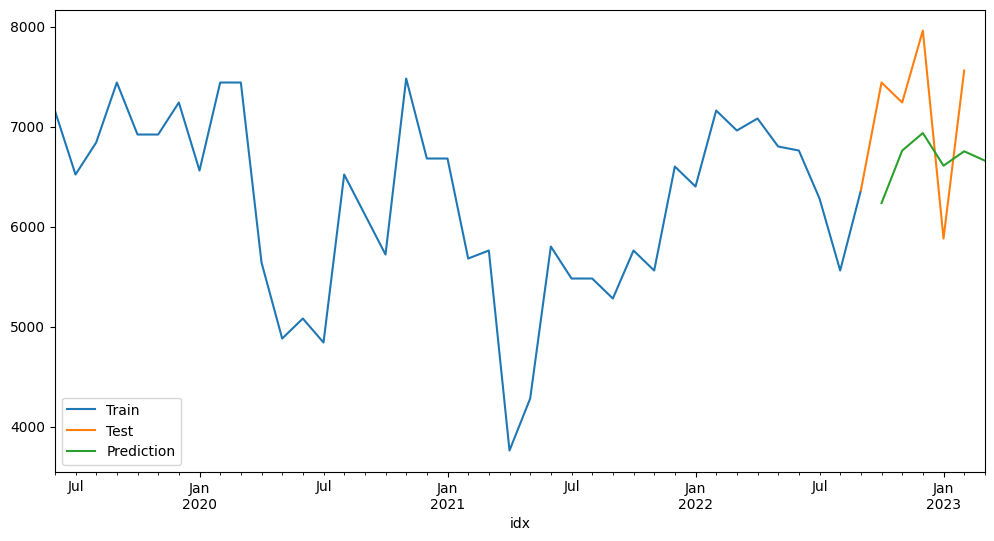

In [94]:
train_data[3001084033].plot(legend=True, label="Train", figsize=(12, 6))
test_data[3001084033].plot(legend=True, label="Test", figsize=(12, 6))
test_predictions.plot(legend=True, label="Prediction", figsize=(12, 6))
test_predictions

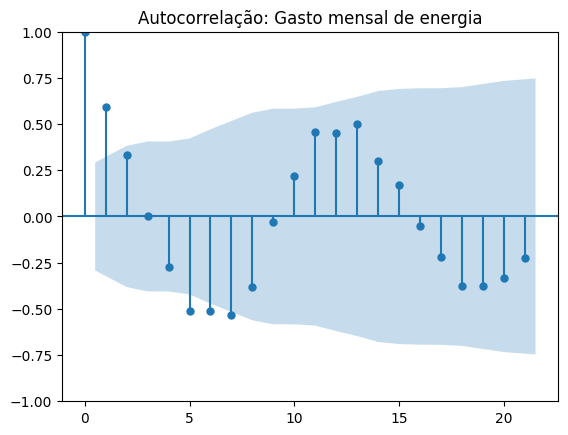

In [141]:
title = "Autocorrelação: Gasto mensal de energia"
lags = 40
plot_acf(df_test_transpose[3011504476], title=title, lags=21);

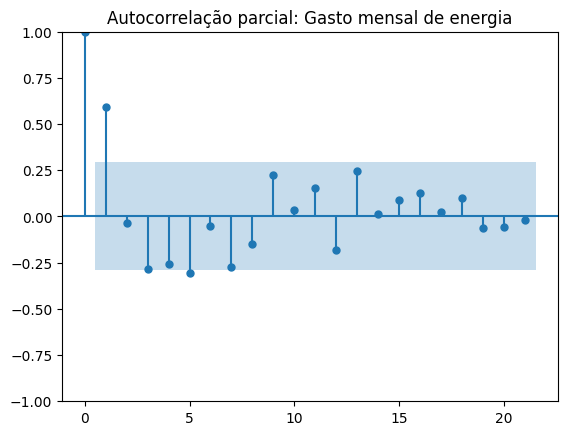

In [140]:
title = "Autocorrelação parcial: Gasto mensal de energia"
plot_pacf(df_test_transpose[3011504476], title=title, lags=21);

Dados são estacionários, então o método de Holt-Winters não é muito efetivo


In [97]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_data.astype(float).describe()

,3003858507,3001084033,3011373971,3001449459,3011504476
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,1662.833333,7073.333333,680.000000,853.333333,2160.000000
std,873.808083,789.700365,219.089023,82.623645,317.993711
min,686.000000,5880.000000,360.000000,760.000000,1720.000000
25%,1241.250000,6580.000000,530.000000,810.000000,2030.000000
50%,1326.000000,7340.000000,740.000000,840.000000,2140.000000
75%,2109.000000,7530.000000,830.000000,870.000000,2250.000000
max,3056.000000,7960.000000,920.000000,1000.000000,2680.000000


In [98]:
mean_absolute_error(test_data[3001084033], test_predictions)

706.2379811262041

In [99]:
np.sqrt(mean_squared_error(test_data[3001084033], test_predictions))

813.7020333364834

In [100]:
adf_test(df_test_transpose[3003858507])

Augmented Dickey-Fuller Test: 
ADF test statistic      -4.487887
p-value                  0.000207
# lags used              4.000000
# observations          40.000000
critical value (1%)     -3.605565
critical value (5%)     -2.937069
critical value (10%)    -2.606986
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [101]:
from statsmodels.graphics.tsaplots import month_plot

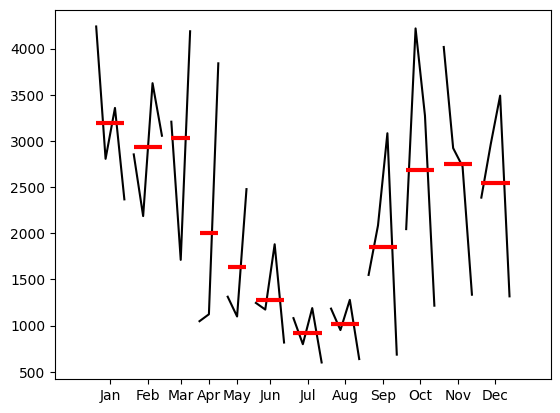

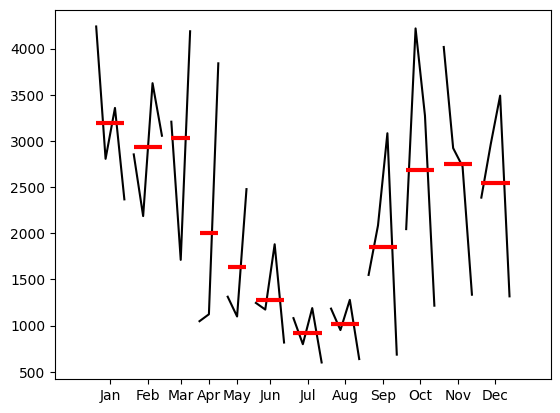

In [102]:
month_plot(df_test_transpose[3003858507])

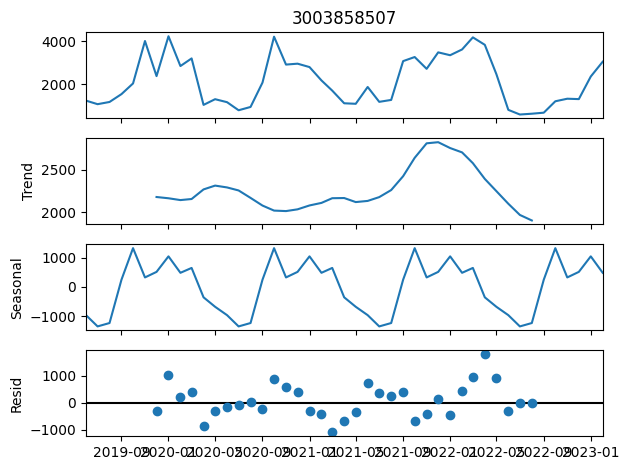

In [139]:
result = seasonal_decompose(df_test_transpose[3003858507], model="add")
result.plot();

In [115]:
help(auto_arima)

Help on function auto_arima in module pmdarima.arima.auto:

auto_arima(y, X=None, start_p=2, d=None, start_q=2, max_p=5, max_d=2, max_q=5, start_P=1, D=None, start_Q=1, max_P=2, max_D=1, max_Q=2, max_order=5, m=1, seasonal=True, stationary=False, information_criterion='aic', alpha=0.05, test='kpss', seasonal_test='ocsb', stepwise=True, n_jobs=1, start_params=None, trend=None, method='lbfgs', maxiter=50, offset_test_args=None, seasonal_test_args=None, suppress_warnings=True, error_action='trace', trace=False, random=False, random_state=None, n_fits=10, return_valid_fits=False, out_of_sample_size=0, scoring='mse', scoring_args=None, with_intercept='auto', sarimax_kwargs=None, **fit_args)
    Automatically discover the optimal order for an ARIMA model.
    
    The auto-ARIMA process seeks to identify the most optimal
    parameters for an ``ARIMA`` model, settling on a single fitted ARIMA model.
    This process is based on the commonly-used R function,
    ``forecast::auto.arima`` [3].


In [105]:
df_test_transpose.head()

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0


In [189]:
auto_arima(
    df_test_transpose[3011373971],
    max_order=None,
    m=12,
    seasonal=True,
    trace=True
).summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=584.847, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=583.545, Time=0.18 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=582.415, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=582.848, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=581.128, Time=0.04 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=582.487, Time=0.11 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=584.404, Time=0.21 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=582.956, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=582.957, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=582.557, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=584.592, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12]             : AIC=579.140, Time=0.01 sec
 ARIMA(0,1,1)(1,0,0)[12]             : AIC=580.536, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[12]             

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   45
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -287.570
Date:                Sat, 11 Nov 2023   AIC                            579.140
Time:                        18:24:08   BIC                            582.708
Sample:                    06-01-2019   HQIC                           580.463
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4056      0.181     -2.237      0.025      -0.761      -0.050
sigma2      2.767e+04   5561.386      4.975      0.000    1.68e+04    3.86e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 8.75
Prob(Q):                              0.90   Prob(JB):                         0.01
Heteroskedasticity (H):               1.01   Skew:                            -0.94
Prob(H) (two-sided):                  0.98   Kurtosis:                         4.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [137]:
auto_arima(
    df_test_transpose[3003858507],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   45
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -367.325
Date:                Sat, 11 Nov 2023   AIC                            740.649
Time:                        15:48:46   BIC                            746.069
Sample:                    06-01-2019   HQIC                           742.670
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    780.1052    428.274      1.822      0.069     -59.296    1619.506
ar.L1          0.6389      0.164      3.907      0.000       0.318       0.959
sigma2       7.16e+05   1.69e+05      4.249      0.000    3.86e+05    1.05e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 2.82
Prob(Q):                              0.85   Prob(JB):                         0.24
Heteroskedasticity (H):               0.58   Skew:                             0.60
Prob(H) (two-sided):                  0.30   Kurtosis:                         3.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [108]:
train = df_test_transpose.iloc[:40]
test = df_test_transpose.iloc[40:]

test = test.astype(float)
train = train.astype(float)

In [166]:
model = SARIMAX(train[3003858507], order=(1, 0, 0), seasonal_order=(0, 1, 1, 12))
results = model.fit()
results.summary()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.89218D+00    |proj g|=  2.58140D-01

At iterate    5    f=  5.84854D+00    |proj g|=  2.71844D-02

At iterate   10    f=  5.84603D+00    |proj g|=  2.80600D-04

At iterate   15    f=  5.84603D+00    |proj g|=  1.53586D-03

At iterate   20    f=  5.84500D+00    |proj g|=  1.93044D-02

At iterate   25    f=  5.83935D+00    |proj g|=  3.71045D-03


 This problem is unconstrained.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     29     33      1     0     0   2.684D-06   5.839D+00
  F =   5.8393038050214816     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                           3003858507   No. Observations:                   40
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -233.572
Date:                              Sat, 11 Nov 2023   AIC                            473.144
Time:                                      16:02:18   BIC                            477.141
Sample:                                  06-01-2019   HQIC                           474.366
                                       - 09-01-2022                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4741      0.191      2.489      0.013       0.101       0.848
ma.S.L12      -0.4642      0.266     -1.742      0.081      -0.986       0.058
sigma2      9.922e+05   3.49e+05      2.843      0.004    3.08e+05    1.68e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.28   Jarque-Bera (JB):                 0.49
Prob(Q):                              0.60   Prob(JB):                         0.78
Heteroskedasticity (H):               1.12   Skew:                             0.14
Prob(H) (two-sided):                  0.87   Kurtosis:                         2.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [167]:
start = len(train)
end = len(train) + len(test) - 1
predictions = results.predict(start=start, end=end, dynamic=False, typ="levels").rename(
    "SARIMA Predictions"
)

In [168]:
for i in range(len(predictions)):
    print(f"predicted={predictions[i]:<11.10}, expected={test[3003858507][i]}")

predicted=2332.690257, expected=1216.0
predicted=2411.045148, expected=1335.0
predicted=2787.861701, expected=1317.0
predicted=3059.444137, expected=2367.0
predicted=2874.151698, expected=3056.0


In [169]:
from statsmodels.tools.eval_measures import rmse

error = rmse(test[3003858507], predictions)
print(f'SARIMA(0,1,3)(1,0,1,12) RMSE Error: {error:11.10}')

SARIMA(0,1,3)(1,0,1,12) RMSE Error: 1008.052789


[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

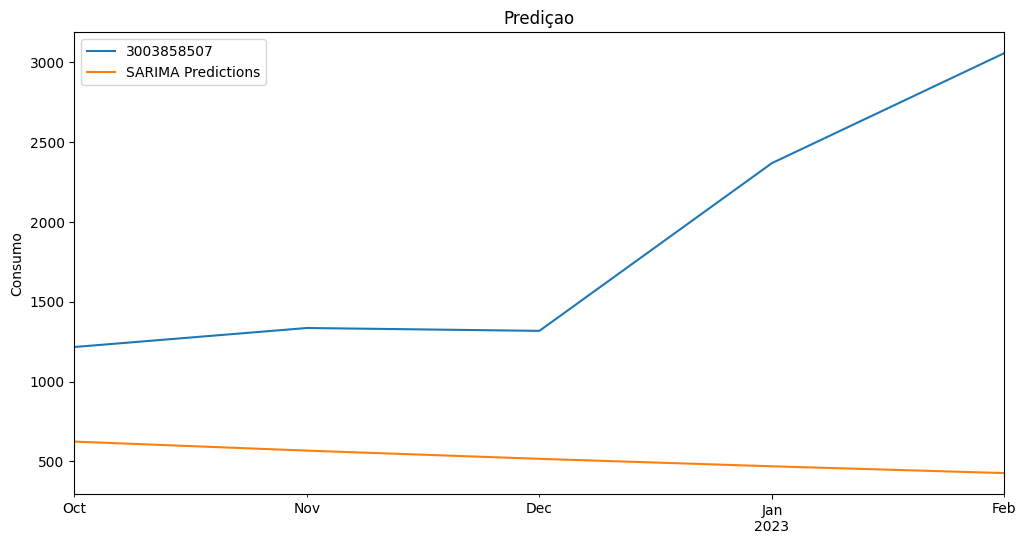

In [148]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = test[3003858507].plot(legend=True, figsize=(12, 6), title=title)
predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)